# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-29 11:00:28.275410: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 11:00:28.827603: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 11:00:28.827950: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 11:00:28.828503: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 11:00:29.113836: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 11:00:29.118632: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/thomas/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir/"train"/"X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir/"train"/"y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir/"test"/"X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir/"test"/"y_test.txt", dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-04-29 11:00:42.431714: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-29 11:00:42.433737: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 6. Train the Teacher Model


In [6]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=teacher_callbacks
)

Epoch 1/40
92/92 [==============================] - 2s 15ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/40
92/92 [==============================] - 1s 11ms/step - loss: 0.1608 - accuracy: 0.9344 - val_loss: 0.1349 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 11ms/step - loss: 0.1035 - accuracy: 0.9568 - val_loss: 0.3582 - val_accuracy: 0.8674
Epoch 4/40
92/92 [==============================] - 1s 11ms/step - loss: 0.0950 - accuracy: 0.9646 - val_loss: 0.1895 - val_accuracy: 0.9341
Epoch 5/40
92/92 [==============================] - 1s 11ms/step - loss: 0.0924 - accuracy: 0.9643 - val_loss: 0.1345 - val_accuracy: 0.9395
Epoch 6/40
92/92 [==============================] - 1s 11ms/step - loss: 0.0671 - accuracy: 0.9743 - val_loss: 0.2264 - val_accuracy: 0.9259
Epoch 7/40
92/92 [==============================] - 1s 11ms/step - loss: 0.0540 - accuracy: 0.9796 - val_loss: 0.1487 - val_accuracy: 0.9443
Epoch 8/40
92

### Teacher Training Curves


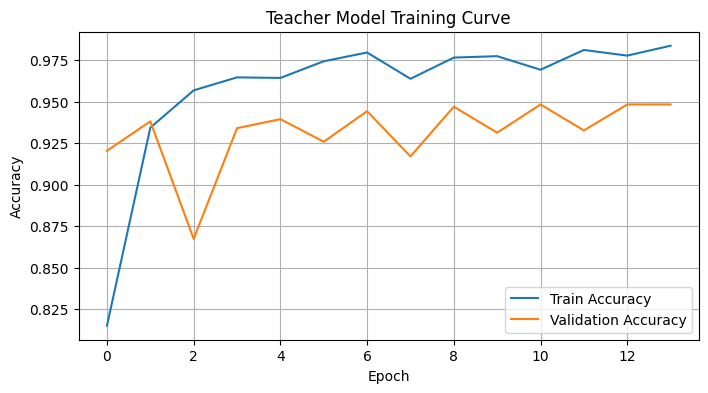

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [8]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=student_callbacks
)

# teacher acc
teacher_test_loss, teacher_test_acc = teacher_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Teacher Model Test Accuracy: {teacher_test_acc:.4f}")

Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.2443 - val_accuracy: 0.9103
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1845 - accuracy: 0.9345 - val_loss: 0.1950 - val_accuracy: 0.9177
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1514 - accuracy: 0.9415 - val_loss: 0.2699 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1158 - accuracy: 0.9565 - val_loss: 0.1503 - val_accuracy: 0.9347
Epoch 5/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0891 - accuracy: 0.9663 - val_loss: 0.1711 - val_accuracy: 0.9252
Epoch 6/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0669 - accuracy: 0.9779 - val_loss: 0.2556 - val_accuracy: 0.9184
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0642 - accuracy: 0.9765 - val_loss: 0.1501 - val_accuracy: 0.9381
Epoch 8/40
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 0.0698 - accuracy: 0.9733 - val_loss: 0.1554 - val_accuracy: 0.9388
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0664 - accuracy: 0.9740 - val_loss: 0.1382 - val_accuracy: 0.9402
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0504 - accuracy: 0.9825 - val_loss: 0.1769 - val_accuracy: 0.9409
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0561 - accuracy: 0.9793 - val_loss: 0.1800 - val_accuracy: 0.9415
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0500 - accuracy: 0.9810 - val_loss: 0.1468 - val_accuracy: 0.9402
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0405 - accuracy: 0.9854 - val_loss: 0.1905 - val_accuracy: 0.9395
Epoch 7/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0501 - accuracy: 0.9804 - val_loss: 0.1401 - val_accuracy: 0.9490
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


In [10]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha

        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(tf.nn.softmax(
                    teacher_predictions / self.temperature, axis=1),
                    tf.nn.softmax(student_predictions / self.temperature, axis=1)) * (self.temperature ** 2)

            loss = (self.alpha * student_loss + (1 - self.alpha) * distillation_loss)

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

student_baseline_test_loss, student_baseline_test_acc = student_baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Student Model Test Accuracy: {student_baseline_test_acc:.4f}")

Student Model Test Accuracy: 0.9359


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [11]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=distillation_callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 7ms/step - accuracy: 0.7970 - student_loss: 0.5460 - distillation_loss: 0.0235 - val_accuracy: 0.9232 - val_student_loss: 0.0672
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9344 - student_loss: 0.1865 - distillation_loss: 0.0065 - val_accuracy: 0.9245 - val_student_loss: 0.0095
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9434 - student_loss: 0.1492 - distillation_loss: 0.0052 - val_accuracy: 0.9218 - val_student_loss: 0.0083
Epoch 4/40
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9592 - student_loss: 0.1118 - distillation_loss: 0.0036 - val_accuracy: 0.9381 - val_student_loss: 0.0046
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9696 - student_loss: 0.0845 - distillation_loss: 0.0023 - val_accuracy: 0.9320 - val_student_loss: 9.0788e-04
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - accuracy: 

## 11. Train the Distilled Student


In [12]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.7718 - student_loss: 0.6051 - distillation_loss: 0.0270 - val_accuracy: 0.9225 - val_student_loss: 0.0604
Epoch 2/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9175 - student_loss: 0.2173 - distillation_loss: 0.0083 - val_accuracy: 0.9055 - val_student_loss: 0.0160
Epoch 3/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9458 - student_loss: 0.1481 - distillation_loss: 0.0052 - val_accuracy: 0.9198 - val_student_loss: 0.0129
Epoch 4/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9583 - student_loss: 0.1145 - distillation_loss: 0.0037 - val_accuracy: 0.9327 - val_student_loss: 0.0066
Epoch 5/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9680 - student_loss: 0.0882 - distillation_loss: 0.0024 - val_accuracy: 0.9320 - val_student_loss: 0.0014
Epoch 6/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.97

### Distillation Training Curves


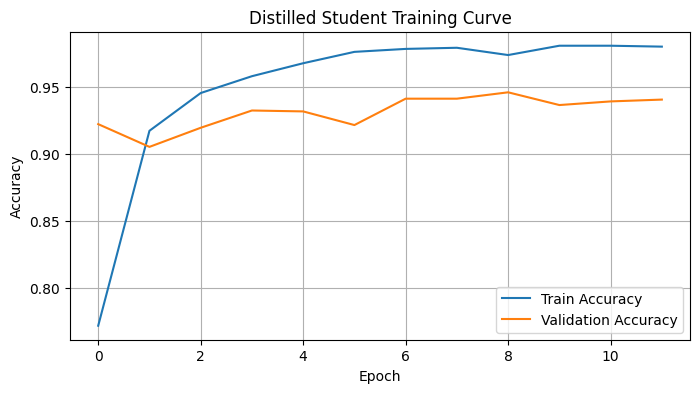

In [13]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9406

                    precision    recall  f1-score   support

           WALKING     0.9493    0.9819    0.9653       496
  WALKING_UPSTAIRS     0.9423    0.9363    0.9393       471
WALKING_DOWNSTAIRS     0.9631    0.9333    0.9480       420
           SITTING     0.9394    0.8839    0.9108       491
          STANDING     0.8645    0.9474    0.9040       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9406      2947
         macro avg     0.9431    0.9400    0.9409      2947
      weighted avg     0.9424    0.9406    0.9409      2947



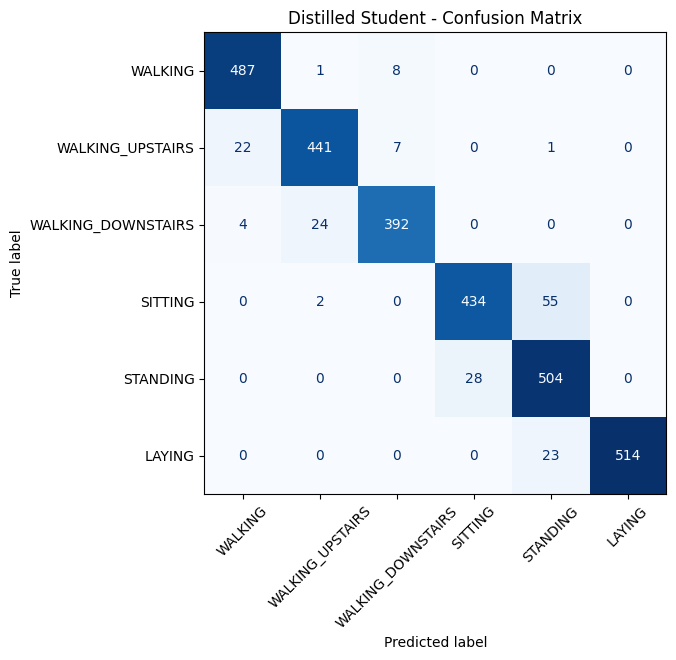

In [14]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [15]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # Yield small batches from X_train for calibration.
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

# Chatgpt helped with debugging this


# Teacher vs Student vs Distilled Student
comparison_results = pd.DataFrame([
    ["Teacher Model", teacher_test_acc, teacher_model.count_params()],
    ["Baseline Student", student_baseline_test_acc, student_baseline_model.count_params()],
    ["Distilled Student", distilled_acc, distilled_student.count_params()],
], columns=["Model", "Test Accuracy", "Parameters"])

comparison_results

,Model,Test Accuracy,Parameters
0,Teacher Model,0.919919,452742
1,Baseline Student,0.935867,80582
2,Distilled Student,0.940618,80582


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [16]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [17]:

pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# Fine-tune the pruned distilled model
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 2s 7ms/step - loss: 0.0428 - accuracy: 0.9871 - val_loss: 0.1435 - val_accuracy: 0.9429
Epoch 2/10
92/92 [==============================] - 0s 4ms/step - loss: 0.0490 - accuracy: 0.9855 - val_loss: 0.1343 - val_accuracy: 0.9449
Epoch 3/10
92/92 [==============================] - 0s 4ms/step - loss: 0.0706 - accuracy: 0.9811 - val_loss: 0.1213 - val_accuracy: 0.9531
Epoch 4/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1010 - accuracy: 0.9733 - val_loss: 0.1411 - val_accuracy: 0.9456
Epoch 5/10
92/92 [==============================] - 0s 5ms/step - loss: 0.2871 - accuracy: 0.9191 - val_loss: 0.1530 - val_accuracy: 0.9545
Epoch 6/10
92/92 [==============================] - 0s 4ms/step - loss: 1.1867 - accuracy: 0.6961 - val_loss: 0.9982 - val_accuracy: 0.6091
Epoch 7/10
92/92 [==============================] - 0s 5ms/step - loss: 1.1941 - accuracy: 0.6312 - val_loss: 1.1723 - val_accuracy: 0.5574
Epoch 8/10
92/92 [==

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [18]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)

pruned_with_mask_size_kb = save_binary_model(
    pruned_with_mask_tflite,
    "pruned_distilled_with_mask_fp32.tflite"
)
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(
    pruned_with_mask_tflite, X_test, y_test
)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpauij57to/assets


INFO:tensorflow:Assets written to: /tmp/tmpauij57to/assets
2026-04-29 11:01:31.348369: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-29 11:01:31.348475: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-29 11:01:31.350611: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpauij57to
2026-04-29 11:01:31.354897: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-29 11:01:31.359777: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpauij57to
2026-04-29 11:01:31.374150: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-29 11:01:31.375864: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-29 11:01:31.430303: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmp7mt0cab7/assets


INFO:tensorflow:Assets written to: /tmp/tmp7mt0cab7/assets
2026-04-29 11:01:32.409938: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-29 11:01:32.410139: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned distilled model with mask accuracy: 0.9362
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9362
Stripped sparse distilled model size (KB): 127.98


2026-04-29 11:01:32.410362: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7mt0cab7
2026-04-29 11:01:32.411109: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-29 11:01:32.411136: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7mt0cab7
2026-04-29 11:01:32.412765: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-29 11:01:32.431329: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp7mt0cab7
2026-04-29 11:01:32.435841: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 25480 microseconds.


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [19]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpnjinzylw/assets


INFO:tensorflow:Assets written to: /tmp/tmpnjinzylw/assets
/home/thomas/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-29 11:01:32.914456: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-29 11:01:32.914521: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-29 11:01:32.914729: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnjinzylw
2026-04-29 11:01:32.915195: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-29 11:01:32.915206: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpnjinzylw
2026-04-29 11:01:32.916162: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
20

Stripped Sparse + INT8 Accuracy: 0.9365
Stripped Sparse + INT8 Size (KB): 81.78


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [20]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp_nfil766/assets


INFO:tensorflow:Assets written to: /tmp/tmp_nfil766/assets
/home/thomas/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-29 11:01:33.513866: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-29 11:01:33.513962: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Stripped Sparse + INT8 Accuracy: 0.9365
Stripped Sparse + INT8 Size (KB): 65.53


2026-04-29 11:01:33.514142: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_nfil766
2026-04-29 11:01:33.514579: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-29 11:01:33.514593: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_nfil766
2026-04-29 11:01:33.516003: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-29 11:01:33.528736: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_nfil766
2026-04-29 11:01:33.539742: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 25595 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [21]:
# You never created/evaluated the plain distilled student FP32 TFLite model yet.
# Run this first:

distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)

distilled_fp32_size_kb = save_binary_model(
    distilled_fp32_tflite,
    "distilled_student_fp32.tflite"
)

distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

print(f"Distilled Student FP32 Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 Size (KB): {distilled_fp32_size_kb:.2f}")

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


INFO:tensorflow:Assets written to: /tmp/tmpnwmebbyp/assets


INFO:tensorflow:Assets written to: /tmp/tmpnwmebbyp/assets
2026-04-29 11:01:34.487392: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-29 11:01:34.487449: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-29 11:01:34.487593: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnwmebbyp
2026-04-29 11:01:34.488194: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-29 11:01:34.488205: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpnwmebbyp
2026-04-29 11:01:34.489503: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-29 11:01:34.502419: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpnwmebbyp
2026-04-29 11:01:34.507171: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Distilled Student FP32 Accuracy: 0.9406
Distilled Student FP32 Size (KB): 316.89


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.940618,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.936206,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.936206,127.984375
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.936546,65.531250


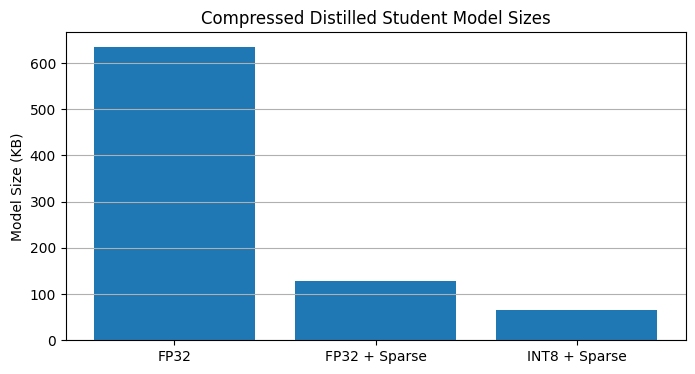

In [22]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


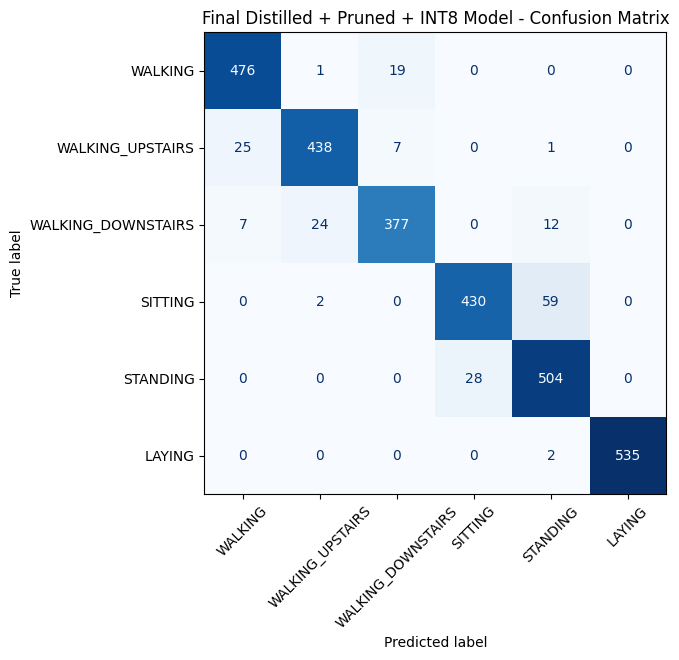

In [23]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?

The baseline student and distilled student used the same small architecture with 80,582 parameters, but the distilled student performed better. The baseline student achieved 93.59% test accuracy, while the distilled student reached 94.06%, showing slightly improved performance without increasing model size.

2. Did **knowledge distillation** help the smaller model retain performance?

Yes. Knowledge distillation improved the small student model by transferring information from the teacher model’s soft outputs. Even though the student remained lightweight, it outperformed the baseline student and also exceeded the teacher model’s 91.99% test accuracy. I think because the teacher may have overfit to the data but was still able to teach certain learned features.

3. What happened to the model size after **pruning** and after **INT8 quantization**?

Pruning with masks attached initially increased file size from 316.9 KB to 634.7 KB because pruning metadata was stored. After stripping the pruning wrappers and applying sparse optimization, the size dropped to 128.0 KB. Applying INT8 quantization reduced it further to 65.5 KB, the smallest model.

4. Which model would you choose for **Arduino deployment**, and why?

I would choose the stripped sparse INT8 distilled student model because it had the smallest size (65.5 KB) while maintaining strong accuracy (93.65%). This makes it ideal for devices with limited flash memory and RAM.

5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?

The final sparse INT8 model combines several TinyML advantages: low storage requirements, efficient integer arithmetic, reduced memory bandwidth, and strong predictive accuracy. It preserves nearly all of the original student model’s performance while being small enough for embedded microcontrollers.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
